# City-day air quality in India (2015–2020)

**Author:** Vineet Shukla

Exploratory analysis of the CPCB `city_day` table: 26 Indian cities, daily PM2.5 and
other pollutants, from 2015-01-01 through 2020-07-01. The modeling target is next-day
PM2.5. This notebook cleans the extract, shows missingness, and plots the patterns the
model has to live with: a skewed distribution, a strong winter peak, and large city gaps.

Figures are written to `reports/figures/`.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.features import add_features, clean, load_raw, supervised_frame, time_split
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.facecolor"] = "white"

def save(fig, name: str) -> None:
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


## Load

The raw file is used as published. Empty pollutant cells stay missing. No values are invented.


In [2]:
raw = load_raw(ROOT / "data" / "city_day.csv")
raw["Date"] = pd.to_datetime(raw["Date"])
print(f"rows {len(raw)}")
print(f"cities {raw['City'].nunique()}")
print(f"date_min {raw['Date'].min().date()}")
print(f"date_max {raw['Date'].max().date()}")
raw.head()


rows 29531
cities 26
date_min 2015-01-01
date_max 2020-07-01


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## Missing values

PM2.5 is missing on a minority of days. PM10, NH3, and Xylene are much sparser. Rows with
a missing PM2.5 cannot be supervised, so they are kept for this picture and dropped only
when a target is required. Other pollutant lags used by the model are median-imputed from
the training period inside the sklearn pipeline, not filled here.


,column,missing_pct
13,Xylene,61.32
3,PM10,37.72
7,NH3,34.97
12,Toluene,27.23
11,Benzene,19.04
14,AQI,15.85
15,AQI_Bucket,15.85
2,PM2.5,15.57
6,NOx,14.17
10,O3,13.62


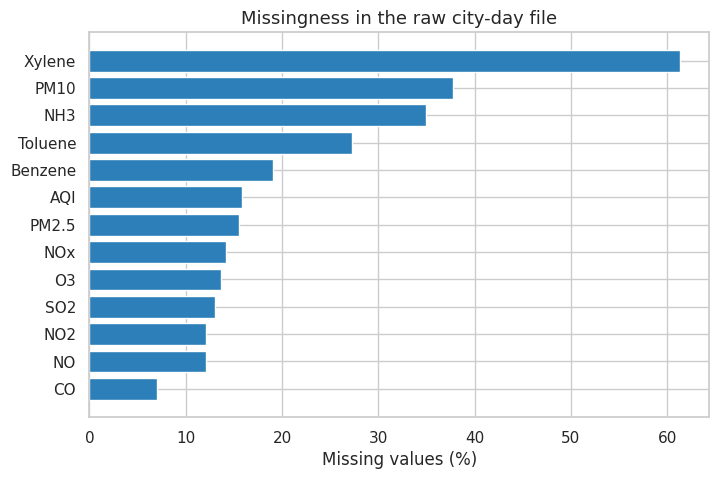

In [3]:
missing_pct = (raw.isna().mean() * 100).rename("missing_pct").reset_index()
missing_pct.columns = ["column", "missing_pct"]
missing_pct = missing_pct.sort_values("missing_pct", ascending=False)
missing_pct["missing_pct"] = missing_pct["missing_pct"].round(2)
display(missing_pct)

plot_df = missing_pct[missing_pct["column"].isin(
    ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]
)].sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["column"], plot_df["missing_pct"], color="#2c7fb8")
ax.set_xlabel("Missing values (%)")
ax.set_title("Missingness in the raw city-day file")
save(fig, "missingness.png")


## Cleaning

`clean` parses dates, coerces numbers, and expands each city onto a daily calendar so that
a lag of 1 is yesterday. On this extract the published dates are already continuous inside
each city's own span, so the row count does not change. Negative numeric readings, if any,
are set to missing.


In [4]:
numeric_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]
negative_counts = {}
for column in numeric_cols:
    values = pd.to_numeric(raw[column], errors="coerce")
    negative_counts[column] = int((values < 0).sum())
print("negative readings", negative_counts)

daily = clean(raw)
print(f"raw_rows {len(raw)}")
print(f"daily_rows {len(daily)}")
print(f"cities {daily['city'].nunique()}")
daily[["city", "date", "pm25", "pm10", "no2", "co", "so2", "o3", "aqi", "aqi_bucket"]].head()


negative readings {'PM2.5': 0, 'PM10': 0, 'NO': 0, 'NO2': 0, 'NOx': 0, 'NH3': 0, 'CO': 0, 'SO2': 0, 'O3': 0, 'Benzene': 0, 'Toluene': 0, 'Xylene': 0, 'AQI': 0}
raw_rows 29531
daily_rows 29531
cities 26


,city,date,pm25,pm10,no2,co,so2,o3,aqi,aqi_bucket
0,Ahmedabad,2015-01-01,NaN,NaN,18.22,0.92,27.64,133.36,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,15.69,0.97,24.55,34.06,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,19.30,17.40,29.07,30.70,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,18.48,1.70,18.59,36.08,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,21.42,22.10,39.33,39.31,NaN,NaN


## PM2.5 distribution


count    24933.00
mean        67.45
std         64.66
min          0.04
25%         28.82
50%         48.57
75%         80.59
max        949.99
pm25_max 949.99


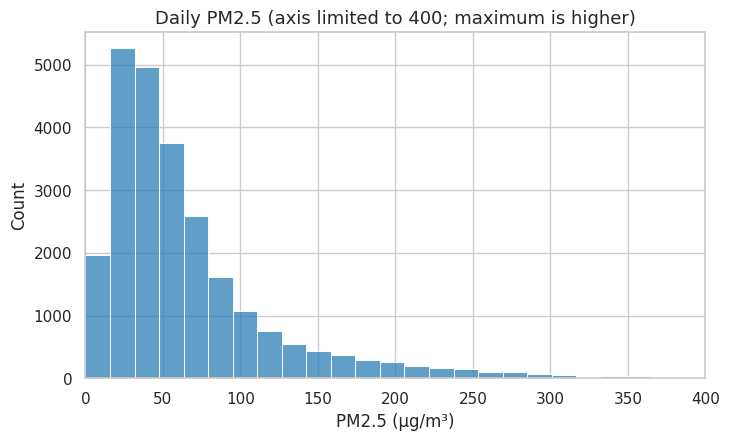

In [5]:
observed = daily["pm25"].dropna()
print(observed.describe().round(2).to_string())
print(f"pm25_max {observed.max():.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(observed, bins=60, ax=ax, color="#2c7fb8", edgecolor="white")
ax.set_xlim(0, 400)
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_title("Daily PM2.5 (axis limited to 400; maximum is higher)")
save(fig, "pm25_distribution.png")


## Seasonality

Months are pooled across years and cities. Winter and post-monsoon days carry much higher
PM2.5 than the monsoon. The season labels used alongside the SQL report are Winter
(Dec–Feb), Summer (Mar–May), Monsoon (Jun–Sep), and Post-monsoon (Oct–Nov).


,month,mean,median,n
0,1,107.76,78.03,2138
1,2,82.90,65.96,2082
2,3,63.93,51.93,2373
3,4,52.64,42.44,2314
4,5,51.31,40.37,2428
5,6,43.37,32.37,2337
6,7,37.75,30.52,1836
7,8,33.78,29.82,1758
8,9,38.00,31.61,1744
9,10,74.65,59.04,1929


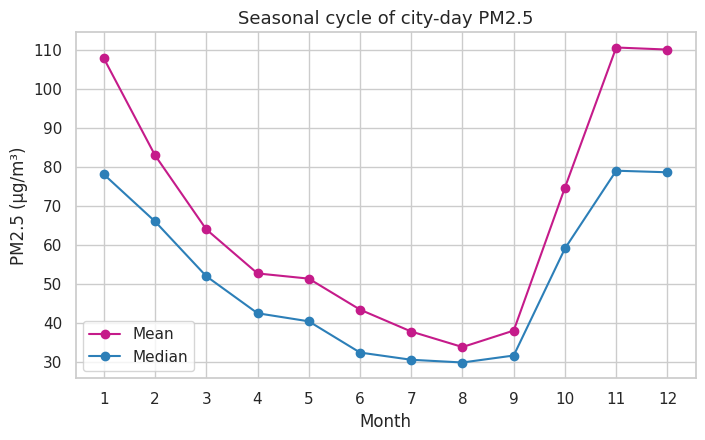

In [6]:
month_means = (
    daily.dropna(subset=["pm25"])
    .groupby(daily["date"].dt.month)["pm25"]
    .agg(mean="mean", median="median", n="size")
    .reset_index()
    .rename(columns={"date": "month"})
)
month_means["mean"] = month_means["mean"].round(2)
month_means["median"] = month_means["median"].round(2)
display(month_means)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(month_means["month"], month_means["mean"], marker="o", color="#c51b8a", label="Mean")
ax.plot(month_means["month"], month_means["median"], marker="o", color="#2c7fb8", label="Median")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Seasonal cycle of city-day PM2.5")
ax.legend()
save(fig, "monthly_seasonality.png")


## City comparison


,city,median,mean,n
10,Delhi,94.62,117.20,2007
21,Patna,91.12,123.50,1537
12,Gurugram,90.15,117.10,1525
19,Lucknow,86.09,109.71,1907
16,Jorapokhar,60.69,64.23,379
6,Brajrajnagar,60.63,64.06,753
0,Ahmedabad,58.37,67.85,1381
15,Jaipur,49.75,54.50,1102
13,Guwahati,46.78,63.69,501
8,Chennai,45.54,50.43,1892


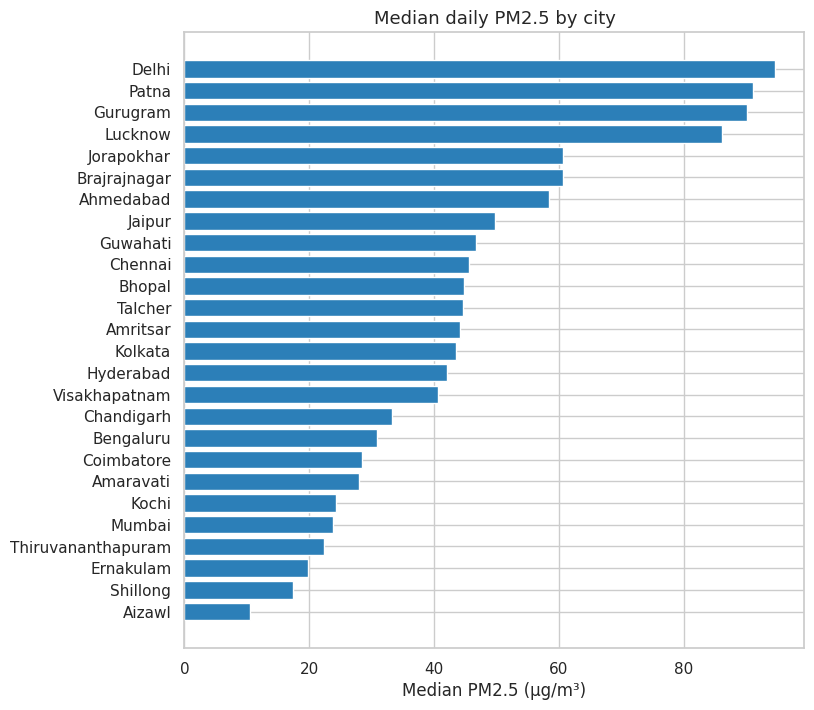

In [7]:
city_stats = (
    daily.dropna(subset=["pm25"])
    .groupby("city")["pm25"]
    .agg(median="median", mean="mean", n="size")
    .reset_index()
    .sort_values("median")
)
city_stats["median"] = city_stats["median"].round(2)
city_stats["mean"] = city_stats["mean"].round(2)
display(city_stats.sort_values("median", ascending=False))

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(city_stats["city"], city_stats["median"], color="#2c7fb8")
ax.set_xlabel("Median PM2.5 (µg/m³)")
ax.set_title("Median daily PM2.5 by city")
save(fig, "city_comparison.png")


## Pollutant correlations

Pairwise complete observations. PM2.5 moves closely with PM10. The association with CO and
SO2 is weak in this daily city aggregate. Same-day AQI is correlated with PM2.5 but is not
used as a model feature, because the published AQI is computed from the pollutants.


,pm25,pm10,no,no2,nox,nh3,co,so2,o3
pm25,1.000,0.846,0.433,0.351,0.437,0.275,0.090,0.132,0.161
pm10,0.846,1.000,0.502,0.464,0.528,0.377,0.113,0.257,0.245
no,0.433,0.502,1.000,0.478,0.795,0.186,0.213,0.170,0.015
no2,0.351,0.464,0.478,1.000,0.628,0.235,0.357,0.392,0.293
nox,0.437,0.528,0.795,0.628,1.000,0.166,0.227,0.238,0.093
nh3,0.275,0.377,0.186,0.235,0.166,1.000,0.105,-0.039,0.095
co,0.090,0.113,0.213,0.357,0.227,0.105,1.000,0.490,0.042
so2,0.132,0.257,0.170,0.392,0.238,-0.039,0.490,1.000,0.162
o3,0.161,0.245,0.015,0.293,0.093,0.095,0.042,0.162,1.000


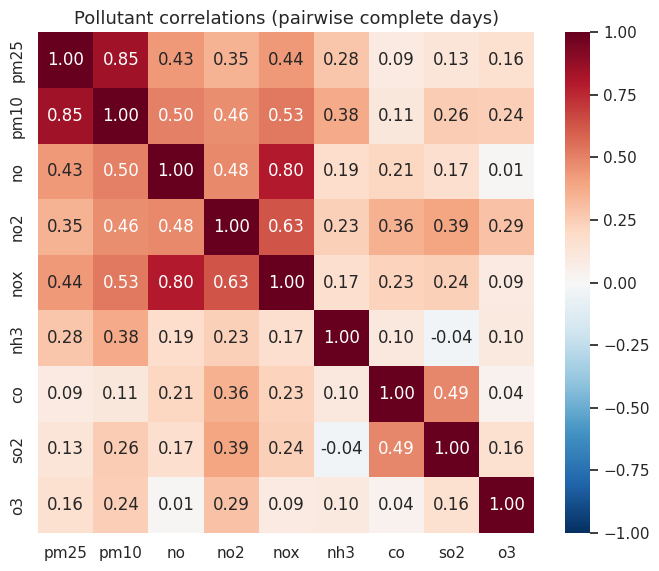

In [8]:
corr_cols = ["pm25", "pm10", "no", "no2", "nox", "nh3", "co", "so2", "o3"]
corr = daily[corr_cols].corr().round(3)
display(corr)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pollutant correlations (pairwise complete days)")
save(fig, "correlation_heatmap.png")


## A few city time series

Monthly means for four long-running cities. Delhi stays well above the southern and
western coastal cities. The 2020 drop is visible, and it mixes the monsoon months present
in every year with the COVID-19 lockdown.


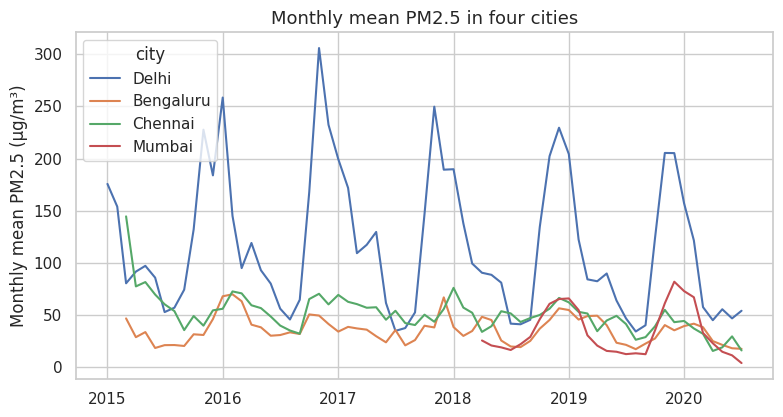

In [9]:
focus = ["Delhi", "Mumbai", "Bengaluru", "Chennai"]
monthly_city = (
    daily[daily["city"].isin(focus)]
    .dropna(subset=["pm25"])
    .assign(month=lambda frame: frame["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "city"], as_index=False)["pm25"]
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=monthly_city, x="month", y="pm25", hue="city", ax=ax)
ax.set_ylabel("Monthly mean PM2.5 (µg/m³)")
ax.set_xlabel("")
ax.set_title("Monthly mean PM2.5 in four cities")
save(fig, "city_timeseries.png")


## What the supervised table keeps

The forecast row needs an observed PM2.5 and an observed PM2.5 from the previous calendar
day. The time split is a single cutoff: the last 20% of remaining dates are the test period,
and cities with no training history are left out of that score.


In [10]:
featured = add_features(daily)
supervised = supervised_frame(featured)
train, test, cutoff, excluded = time_split(supervised)
print(f"supervised_rows {len(supervised)}")
print(f"n_train {len(train)}")
print(f"n_test {len(test)}")
print(f"cutoff {cutoff.date().isoformat()}")
print(f"excluded {excluded}")

top = city_stats.sort_values("median", ascending=False).iloc[0]
bottom = city_stats.sort_values("median", ascending=True).iloc[0]
peak_month = month_means.loc[month_means["mean"].idxmax()]
low_month = month_means.loc[month_means["mean"].idxmin()]

summary = {
    "n_rows": str(len(raw)),
    "n_cities": str(raw["City"].nunique()),
    "date_min": raw["Date"].min().date().isoformat(),
    "date_max": raw["Date"].max().date().isoformat(),
    "daily_rows": str(len(daily)),
    "pm25_missing_pct": f"{raw['PM2.5'].isna().mean() * 100:.2f}",
    "pm25_mean": f"{observed.mean():.2f}",
    "pm25_median": f"{observed.median():.2f}",
    "pm25_max": f"{observed.max():.2f}",
    "negative_readings": str(sum(negative_counts.values())),
    "highest_median_city": str(top["city"]),
    "highest_median_pm25": f"{top['median']:.2f}",
    "lowest_median_city": str(bottom["city"]),
    "lowest_median_pm25": f"{bottom['median']:.2f}",
    "highest_month": str(int(peak_month["month"])),
    "highest_month_mean_pm25": f"{peak_month['mean']:.2f}",
    "lowest_month": str(int(low_month["month"])),
    "lowest_month_mean_pm25": f"{low_month['mean']:.2f}",
    "pm25_pm10_corr": f"{corr.loc['pm25', 'pm10']:.3f}",
    "supervised_rows": str(len(supervised)),
    "cutoff": cutoff.date().isoformat(),
    "n_train": str(len(train)),
    "n_test": str(len(test)),
}
import json
(ROOT / "reports" / "eda_summary.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
print(json.dumps(summary, indent=2))


supervised_rows 24644
n_train 15760
n_test 7288
cutoff 2019-05-27
excluded ['Aizawl', 'Bhopal', 'Chandigarh', 'Coimbatore', 'Ernakulam', 'Kochi', 'Shillong']
{
  "n_rows": "29531",
  "n_cities": "26",
  "date_min": "2015-01-01",
  "date_max": "2020-07-01",
  "daily_rows": "29531",
  "pm25_missing_pct": "15.57",
  "pm25_mean": "67.45",
  "pm25_median": "48.57",
  "pm25_max": "949.99",
  "negative_readings": "0",
  "highest_median_city": "Delhi",
  "highest_median_pm25": "94.62",
  "lowest_median_city": "Aizawl",
  "lowest_median_pm25": "10.48",
  "highest_month": "11",
  "highest_month_mean_pm25": "110.53",
  "lowest_month": "8",
  "lowest_month_mean_pm25": "33.78",
  "pm25_pm10_corr": "0.846",
  "supervised_rows": "24644",
  "cutoff": "2019-05-27",
  "n_train": "15760",
  "n_test": "7288"
}
